# Algoritmos

## Gerando dados

In [1]:
import os
try:
    os.chdir("aulas_teoricas")
except:
    pass

from joblib import load, dump

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from src.line_equation import Line_equation

In [2]:
df_3 = load('./data/05_aula_df_3')
df_3.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1,1


In [3]:
def ponto_estrela(df_sample: pd.DataFrame, x: str, y: str) -> tuple:
    x_estrela = np.random.randint(
        np.min(df_sample[x]),
        np.max(df_sample[x]),
    )
    y_estrela = np.random.randint(
        np.min(df_sample[y]),
        np.max(df_sample[y]),
    )
    return x_estrela, y_estrela

def seta_estrela(
        df_sample: pd.DataFrame,
        x: str,
        y: str,
        color: str = 'g',
        seta: bool = False,
        n_setas: int = 5) -> None:
    sns.scatterplot(
        x=x,
        y=y,
        hue='k-means',
        data=df_sample,
    )
    x_estrela, y_estrela = ponto_estrela(df_sample, x, y)
    plt.plot(
        x_estrela,
        y_estrela,
        '*' + color,
        markersize=25
    )
    if seta:
        for _ in range(n_setas):
            index = df_sample[x].sample(1).index[0]
            dx = df_sample[x][index] - x_estrela
            dy = df_sample[y][index] - y_estrela
            plt.arrow(
                x_estrela,
                y_estrela, 
                dx,
                dy,
                head_width=1,
                head_length=1,
                length_includes_head=True,
                color=color,
            )
    return None

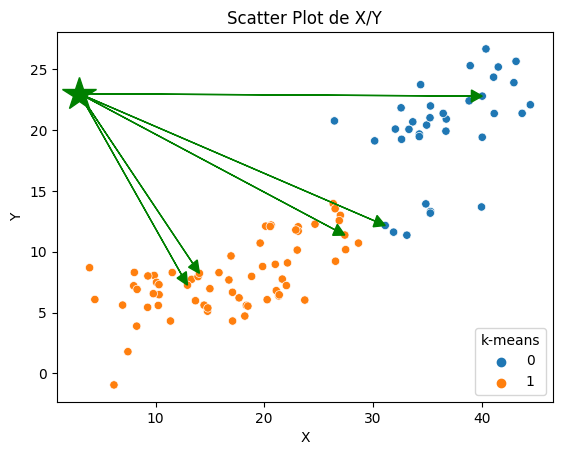

In [4]:
grafico = {
    "df_sample": df_3,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## k-NN

In [5]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
df_3['DBSCAN_1'].value_counts()

 1    62
 0    25
-1    13
Name: DBSCAN_1, dtype: int64

In [7]:
# Example with a hypothetical dataset

X = df_3[df_3.columns[:7]].copy()
y = df_3['DBSCAN_1']
X_train, X_test, y_train, y_test = train_test_split(
                                                        X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state=42
                                                    )
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 7)
(20, 7)
(80,)
(20,)


In [8]:
X_train.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean
137,7,1,9.272485,0.425720,5.425720,17,14
83,11,3,10.089934,2.484196,7.484196,28,10
196,19,7,15.836692,8.281164,8.281164,36,15
149,25,10,23.037599,10.138011,10.138011,14,11
164,9,2,8.264474,-1.121012,3.878988,37,15


In [9]:
y_train.value_counts()

 1    50
 0    19
-1    11
Name: DBSCAN_1, dtype: int64

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
k = len(y_train.value_counts().values)  # Choose an appropriate value for K
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
y_pred = knn_classifier.predict(X_test_scaled)
np.unique(y_pred, return_counts=True)

(array([0, 1]), array([ 7, 13]))

In [13]:
def metricas(y_test: pd.Series | list, y_pred: np.ndarray, target: str) -> None:
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
                    confusion_matrix=cm,
                    display_labels=y_test.value_counts().index,
    )
    disp.plot(cmap=plt.cm.Greens)
    plt.title(f"{target}'s cluster: Accuracy {accuracy:.2f}")
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [14]:
def treinamento_modelos_knn(target: str, df_teste: pd.DataFrame = df_3) -> tuple:
    # Divisão das variáveis dependente e independentes
    X = df_teste[df_teste.columns[:7]].copy()
    y = df_teste[target]

    # Divisão de teste e treino
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Padronização dos dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Determinação do modelo
    k = len(y_train.value_counts().values)  # Choose an appropriate value for K
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    knn_classifier.fit(X_train_scaled, y_train)

    # Determinação de predição
    y_pred = knn_classifier.predict(X_test_scaled)

    return y_test, y_pred, knn_classifier

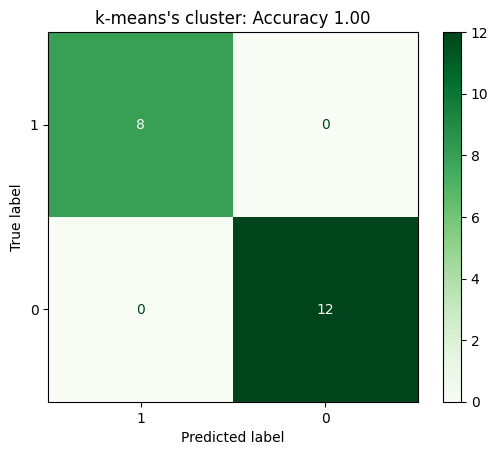


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [15]:
c = 0
target = df_3.columns[-4:][c]
y_test, y_pred, _ = treinamento_modelos_knn(target=target)
metricas(y_pred=y_pred, y_test=y_test, target=target)

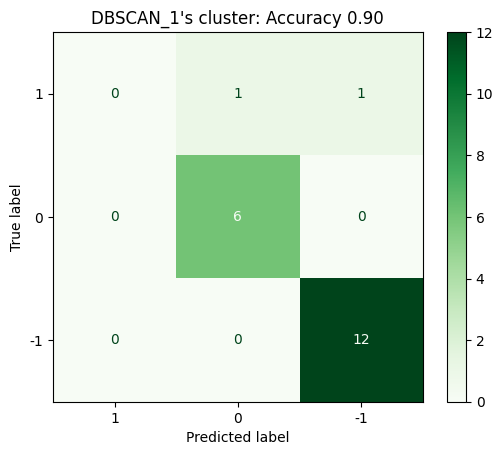


Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         2
           0       0.86      1.00      0.92         6
           1       0.92      1.00      0.96        12

    accuracy                           0.90        20
   macro avg       0.59      0.67      0.63        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
c += 1
target = df_3.columns[-4:][c]
y_test, y_pred, _ = treinamento_modelos_knn(target=target)
metricas(y_pred=y_pred, y_test=y_test, target=target)

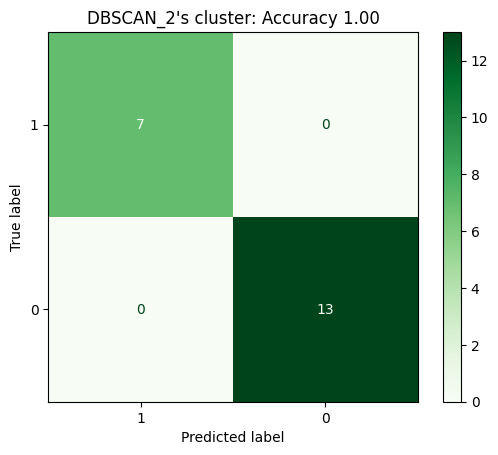


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        13

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [17]:
c += 1
target = df_3.columns[-4:][c]
y_test, y_pred, _ = treinamento_modelos_knn(target=target)
metricas(y_pred=y_pred, y_test=y_test, target=target)

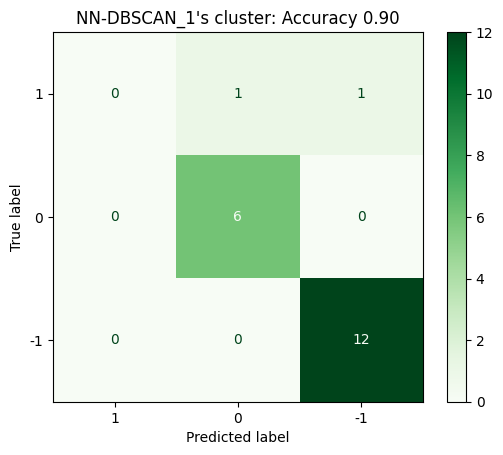


Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         2
           0       0.86      1.00      0.92         6
           1       0.92      1.00      0.96        12

    accuracy                           0.90        20
   macro avg       0.59      0.67      0.63        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
c += 1
target = df_3.columns[-4:][c]
y_test, y_pred, _ = treinamento_modelos_knn(target=target)
metricas(y_pred=y_pred, y_test=y_test, target=target)

## Regressão Logistica

### Probabilidade

In [19]:
target

'NN-DBSCAN_1'

In [20]:
# Determinação de predição # Padronização dos dados
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(df_3[df_3.columns[:7]])

_, _, modelo_knn = treinamento_modelos_knn(target=target)
y_pred = modelo_knn.predict(X_test_scaled)
y_pred.shape

(100,)

In [21]:
x = 'x_noise'
y = 'y_noise_new'

colunas_classes = [x, y]
[colunas_classes.append(i) for i in df_3.columns[-4:]]

df_4 = df_3[colunas_classes].copy()
df_4['k-NN'] = y_pred
df_4.head()

,x_noise,y_noise_new,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k-NN
53,41.101260,24.359319,0,0,0,0,0
93,9.876045,8.050423,1,1,1,1,1
20,36.714018,19.920509,0,0,0,0,0
177,13.314530,7.728269,1,1,1,1,1
26,17.686336,6.206506,1,1,1,1,1


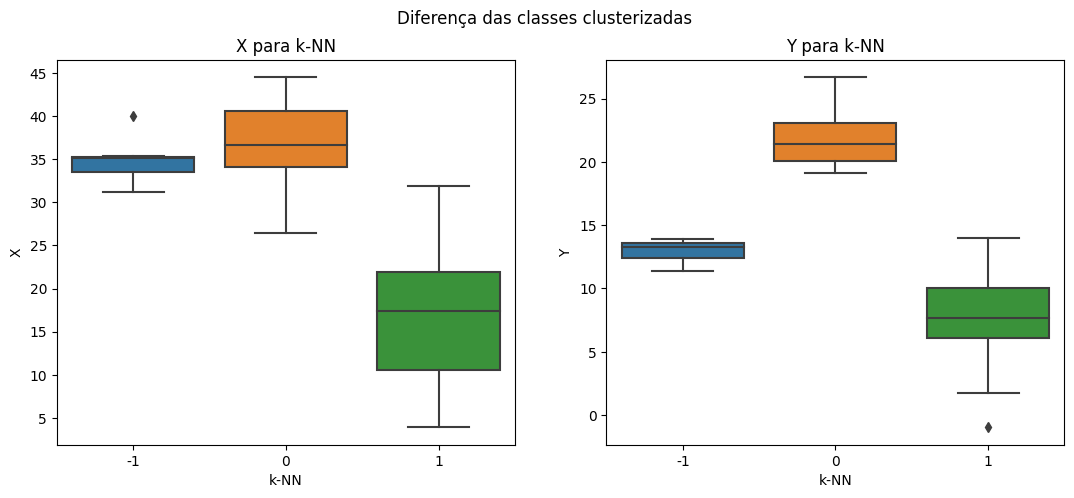

In [22]:
x_cluster = 'k-NN'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_4,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_4,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

In [23]:
df_4['class_'+y] = pd.qcut(x=df_4[y], q=2, labels=["min", "max"])
df_4.head()

,x_noise,y_noise_new,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k-NN,class_y_noise_new
53,41.101260,24.359319,0,0,0,0,0,max
93,9.876045,8.050423,1,1,1,1,1,min
20,36.714018,19.920509,0,0,0,0,0,max
177,13.314530,7.728269,1,1,1,1,1,min
26,17.686336,6.206506,1,1,1,1,1,min


In [24]:
df_4 = df_4[df_4.columns[[0, 1, 7, 2, 3, 4, 5, 6]]].copy()
df_4.head()

,x_noise,y_noise_new,class_y_noise_new,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k-NN
53,41.101260,24.359319,max,0,0,0,0,0
93,9.876045,8.050423,min,1,1,1,1,1
20,36.714018,19.920509,max,0,0,0,0,0
177,13.314530,7.728269,min,1,1,1,1,1
26,17.686336,6.206506,min,1,1,1,1,1


In [25]:
df_4.rename(columns={
                    'x_noise':'indep_1',
                    'y_noise_new':'indep_2',
                    'class_y_noise_new':'indep_3',
                    'k-means':'k_means',
                    'NN-k-means':'NN_k_means',
                    'k-NN':'k_NN',
                }, inplace=True
            )

df_4.head()

,indep_1,indep_2,indep_3,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
53,41.101260,24.359319,max,0,0,0,0,0
93,9.876045,8.050423,min,1,1,1,1,1
20,36.714018,19.920509,max,0,0,0,0,0
177,13.314530,7.728269,min,1,1,1,1,1
26,17.686336,6.206506,min,1,1,1,1,1


In [26]:
df_4['indep_3'].value_counts()

min    50
max    50
Name: indep_3, dtype: int64

In [27]:
np.random.seed(42)
df_4['indep_3'] = ["max" if i == 0 else "min" for i in np.random.randint(0, 2, len(df_4))]
df_4['indep_3'] = df_4['indep_3'].astype('category')
df_4['indep_3'].value_counts()

min    56
max    44
Name: indep_3, dtype: int64

In [28]:
df_4['indep_4'] = pd.qcut(x=df_4['indep_2'], q=3, labels=["min", "med", "max"])
df_4['indep_4'].value_counts()

min    34
med    33
max    33
Name: indep_4, dtype: int64

In [29]:
df_4['indep_1'] = [int(i//1) for i in df_4['indep_1']]
df_4 = round(df_4[df_4.columns[[0, 1, 2, 8, 3, 4, 5, 6, 7]]], 2).copy()
df_4.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
53,41,24.36,max,max,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1


In [ ]:
# dump(df_4, './data/05_aula_df_4')
df_4 = load('./data/05_aula_df_4')
df_4.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
53,41,24.36,max,max,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1


In [31]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100 entries, 53 to 45
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   indep_1      100 non-null    int64   
 1   indep_2      100 non-null    float64 
 2   indep_3      100 non-null    category
 3   indep_4      100 non-null    category
 4   k_means      100 non-null    int64   
 5   DBSCAN_1     100 non-null    int64   
 6   DBSCAN_2     100 non-null    int64   
 7   NN-DBSCAN_1  100 non-null    int64   
 8   k_NN         100 non-null    int64   
dtypes: category(2), float64(1), int64(6)
memory usage: 6.5 KB


In [32]:
df_4_copy = df_4.copy()
curva = Line_equation(
    dados=df_4_copy.loc[:, ['indep_1', 'indep_2']],
    coluna_x='indep_1',
    coluna_y='indep_2',
)
df_4_copy.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
53,41,24.36,max,max,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1


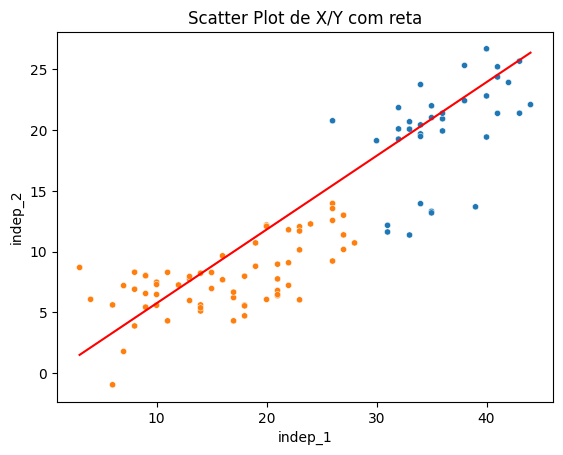

In [33]:
dados_reta = [ 
              df_4_copy['indep_2'].min() / df_4_copy['indep_1'].min(),
              df_4_copy['indep_2'].max() / df_4_copy['indep_1'].max()
        ]
df_4_copy['indep_2_cal'] = df_4_copy['indep_1'].apply(
                                                        curva.reta,
                                                        args=dados_reta
                                                    )
sns.scatterplot(
    x='indep_1',
    y='indep_2',
    hue='k_means',
    legend=False,
    s=20,
    # palette=palette,
    data=df_4_copy
)
sns.lineplot(
    x='indep_1',
    y='indep_2_cal',
    data=df_4_copy,
    c='r',
)
plt.title('Scatter Plot de X/Y com reta')
plt.xlabel('indep_1')
plt.ylabel('indep_2')
plt.show()

In [34]:
def calcula_indicadores(
        independente: str,
        dependente: str,
        df: pd.DataFrame,
        categoria: bool = False,
        bins: int = 5,
    ) -> pd.DataFrame:
    '''
    Função que calcula indices de bivariadas categórias e dependente
    :param independente (str): Variável independente;
    :param dependente (str): Variável dependente;
    :param df (pd.DataFrame): DataFrame contendo o conjunto de dados
    :param categoria (bool) = False: Informa se a variável independente 
                                        é categorica;
    :param bins (int) = 5: Número de categorias para divisão da variável 
                            independente;
    :return tab (pd.DataFrame): DataFrame com os indices;
    '''
    if categoria:
        df[independente+"_cat"] = pd.qcut(x=df[independente], q=bins)
        independente += "_cat"
        
    tab = pd.crosstab(df[independente], df[dependente], margins=True)
    odds_all = tab.iloc[2, 1] / tab.iloc[2, 0]
    tab = (
        tab.assign(prob = tab["All"] / tab.loc['All', 'All'])               # Probabilidade de ser mulher ou homem no conjunto de dados
        .assign(risck_event = tab[1]/tab['All'])                            # Risco do evento (probabilidede) de uma mulher ou de um homem estar doente
        .assign(odds = tab[1] / tab[0])                                     # Chance (odds) de uma mulher ou de um homem estar doente
        .assign(odds_ratio = (tab.iloc[:, 1] / tab.iloc[:, 0])/(odds_all))  # A razão entre as chances de estar doente para mulheres e homens
        .assign(log_odds = np.log(tab.loc[:, 1] / tab.loc[:, 0]))           # Logaritmo da chance
        .assign(woe = np.log(                                               # Logaritmo da razão da chance ou Weigth of Evidence
            (tab.iloc[:, 1] / tab.iloc[:, 0])/(odds_all)
        ))
    )
    tab['log_odds'] = [x if x != np.inf*-1 else np.nan for x in tab['log_odds']]
    tab['woe'] = [x if x != np.inf*-1 else np.nan for x in tab['woe']]
    
    print(f"Flag negativo: {tab.loc['All', 0]}")
    print(f"Flag positivo: {tab.loc['All', 1]}")
    print(f"Total: {tab.loc['All', 'All']}")

    if categoria:
        df.drop(independente, axis='columns', inplace=True)

    return tab

In [35]:
calcula_indicadores(independente="indep_3", dependente='k_means', df=df_4)

Flag negativo: 35
Flag positivo: 65
Total: 100


k_means,0,1,All,prob,risck_event,odds,odds_ratio,log_odds,woe
indep_3,,,,,,,,,
max,18,26,44,0.44,0.590909,1.444444,0.777778,0.367725,-0.251314
min,17,39,56,0.56,0.696429,2.294118,1.235294,0.830348,0.211309
All,35,65,100,1.00,0.650000,1.857143,1.000000,0.619039,0.000000


### Modelo

In [36]:
# Modelagem
import statsmodels.formula.api as smf

# Métricas
from sklearn import metrics
from scipy.stats import ks_2samp # Two-sample Kolmogorov-Smirnov test. Two independent samples to determine if they are statistically different. 

In [37]:
def train_test_df(df: pd.DataFrame) -> tuple:
    '''    Função que divide o DataFrame em treino e teste
    '''
    index = df.sample(frac=0.3, random_state=42).index
    df_train = df.loc[[i for i in df.index if i not in index], :]
    df_test = df.loc[index, :]

    print(f"df_train: {df_train.shape}")
    print(f"df_test: {df_test.shape}")

    return df_train, df_test

In [38]:
df_4_train, df_4_test = train_test_df(df_4)
df_4_train.head()

df_train: (70, 9)
df_test: (30, 9)


,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
93,9,8.05,min,med,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1
0,21,6.37,min,min,1,1,1,1,1
154,40,22.80,max,max,0,0,0,0,0


In [39]:
df_4_test.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN
132,18,5.53,min,min,1,1,1,1,1
143,14,5.61,min,min,1,1,1,1,1
121,14,5.37,min,min,1,1,1,1,1
91,22,7.22,min,min,1,1,1,1,1
74,20,12.19,min,med,1,1,1,1,1


In [40]:
# Inserindo novas variáveis
modelo = '''
            k_means ~ 
            indep_1
'''

reglog = smf.logit(
    modelo,
    data=df_4_train
).fit()

reglog.summary()

         Current function value: 0.000000
         Iterations: 35


/usr/local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                k_means   No. Observations:                   70
Model:                          Logit   Df Residuals:                       68
Method:                           MLE   Df Model:                            1
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                   1.000
Time:                        20:31:59   Log-Likelihood:            -1.2800e-06
converged:                      False   LL-Null:                       -45.623
Covariance Type:            nonrobust   LLR p-value:                 1.269e-21
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    280.4598   1.74e+04      0.016      0.987   -3.38e+04    3.43e+04
indep_1       -9.5088    589.941     -0.016      0.987   -1165.772    1146.755
==============================================================================

Complete Separation: The results show that there iscomplete separation or perfect prediction.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

In [41]:
reglog.params

Intercept    280.459827
indep_1       -9.508832
dtype: float64

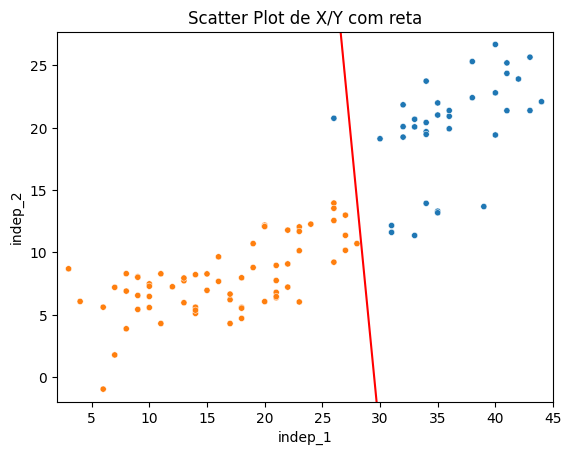

In [42]:
dados_reta = [ 
              reglog.params[0],
              reglog.params[1]
        ]
df_4_copy['indep_2_cal'] = df_4_copy['indep_1'].apply(
                                                        curva.reta,
                                                        args=dados_reta
                                                    )
sns.scatterplot(
    x='indep_1',
    y='indep_2',
    hue='k_means',
    legend=False,
    s=20,
    data=df_4_copy
)
sns.lineplot(
    x='indep_1',
    y='indep_2_cal',
    data=df_4_copy,
    c='r',
)
plt.title('Scatter Plot de X/Y com reta')
plt.xlabel('indep_1')
plt.xlim(df_4_copy['indep_1'].min()-1, df_4_copy['indep_1'].max()+1)
plt.ylabel('indep_2')
plt.ylim(df_4_copy['indep_2'].min()-1, df_4_copy['indep_2'].max()+1)
plt.show()

In [43]:
def retorna_classe(pred: pd.Series) -> list:
    '''
    Função que retorna a classe de predição
    :param pred (pd.Series): Previsão do modelo
    :return (list): Classe de predição
    '''
    retorno = [0 if i <= 0.5 else 1 for i in pred]
    return retorno

In [44]:
df_4_copy.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,indep_2_cal
53,41,24.36,max,max,0,0,0,0,0,-109.402295
93,9,8.05,min,med,1,1,1,1,1,194.880336
20,36,19.92,max,max,0,0,0,0,0,-61.858134
177,13,7.73,max,min,1,1,1,1,1,156.845007
26,17,6.21,max,min,1,1,1,1,1,118.809679


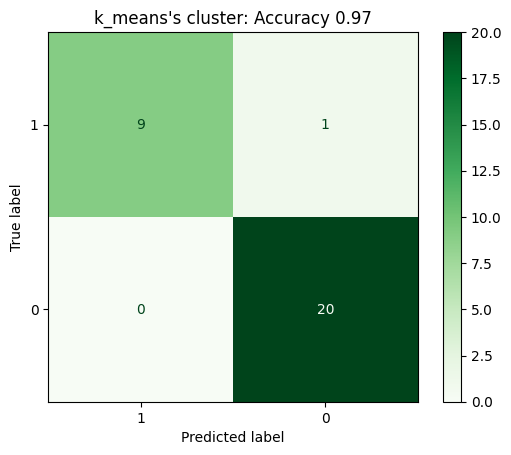


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.95      1.00      0.98        20

    accuracy                           0.97        30
   macro avg       0.98      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



In [45]:
y_pred = retorna_classe(reglog.predict(df_4_test))
y_test = df_4_test['k_means']
target = 'k_means'
metricas(y_pred=y_pred, y_test=y_test, target=target)

In [46]:
def curva_roc(df: pd.DataFrame, flag: str, predito: pd.Series) -> None:
    flag_serie = df.loc[:, flag]
    # Plotando a curva ROC
    fpr, tpr, _ = metrics.roc_curve(flag_serie, predito)

    plt.figure()
    lw = 2

    fpr, tpr, _ = metrics.roc_curve(flag_serie, predito)
    auc_ = metrics.auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange',
            lw=lw, label='ROC curve (area = %0.2f)' % auc_)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) for {flag}')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [47]:
def grafico_ks(df: pd.DataFrame, flag: str, predito: pd.Series) -> None:
    # Plotagem da métrica KS (Kolmogorov-Smirnov)
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    index = df[df[flag] == 1].index
    score_pop1 = predito.loc[index]
    ax.plot(
        np.sort(score_pop1),
        np.linspace(0, 1, len(score_pop1), endpoint=False),
        label='Cluster 1'
    )

    index = df[df[flag] != 1].index
    score_pop2 = predito.loc[index]
    ax.plot(
        np.sort(score_pop2),
        np.linspace(0, 1, len(score_pop2), endpoint=False),
        label='Cluster 0'
    )
    ax.legend()

    plt.title(f"Gráfico KS {flag}")
    ax.set_xlabel('P')
    ax.set_ylabel('Função Distribuição Acumulada')
    plt.show()

    y_pred = retorna_classe(reglog.predict(df))
    metricas(y_pred=y_pred, y_test=df[flag], target=flag)

    return None

In [48]:
def metricas_pontuais(df: pd.DataFrame, flag: str, predito: pd.Series) -> None:
      #  Acurácia
      acc = metrics.accuracy_score(df[flag], predito > .5)

      # Precision
      precision = metrics.precision_score(df[flag], predito > .5)

      # Recall
      recall = metrics.recall_score(df[flag], predito > .5)

      # F1-score
      f1_score = metrics.f1_score(df[flag], predito > .5)

      #KS
      index = df[df[flag] == 1].index
      score_pop1 = reglog.predict(df).loc[index]
      
      index = df[df[flag] != 1].index
      score_pop2 = reglog.predict(df).loc[index]
      ks = ks_2samp(score_pop1, score_pop2).statistic
      
      #AUC
      fpr, tpr, _ = metrics.roc_curve(df[flag], predito)
      auc = metrics.auc(fpr, tpr)

      #Gini
      gini = 2*auc -1

      print(
            f'''
{flag}:
Acurácia: {acc*100:.2f}%
Precision: {precision*100:.2f}%
Recall: {recall*100:.2f}%
F1-Score: {f1_score*100:.2f}%
KS: {ks*100:.2f}%
AUC: {auc*100:.2f}%
GINI: {gini*100:.2f}%
            '''
      )

      return None

In [49]:
def modelos_relog(flag: str, modelo: str) -> None:
    reglog = smf.logit(
        modelo,
        data=df_4_train
    ).fit()

    predito = reglog.predict(df_4_test)
    
    dict_display = {
        'df': df_4_test,
        'flag': flag,
        'predito': predito
    }

    metricas_pontuais(**dict_display)
    display(reglog.summary())
    curva_roc(**dict_display)
    grafico_ks(**dict_display)

    return None

In [50]:
modelos_cluster = df_4.columns[4:]
modelos_cluster

Index(['k_means', 'DBSCAN_1', 'DBSCAN_2', 'NN-DBSCAN_1', 'k_NN'], dtype='object')

         Current function value: 0.000000
         Iterations: 35

k_means:
Acurácia: 96.67%
Precision: 95.24%
Recall: 100.00%
F1-Score: 97.56%
KS: 95.00%
AUC: 99.50%
GINI: 99.00%
            


/usr/local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                k_means   No. Observations:                   70
Model:                          Logit   Df Residuals:                       68
Method:                           MLE   Df Model:                            1
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                   1.000
Time:                        20:32:00   Log-Likelihood:            -1.2800e-06
converged:                      False   LL-Null:                       -45.623
Covariance Type:            nonrobust   LLR p-value:                 1.269e-21
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    280.4598   1.74e+04      0.016      0.987   -3.38e+04    3.43e+04
indep_1       -9.5088    589.941     -0.016      0.987   -1165.772    1146.755
==============================================================================

Complete Separation: The results show that there iscomplete separation or perfect prediction.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

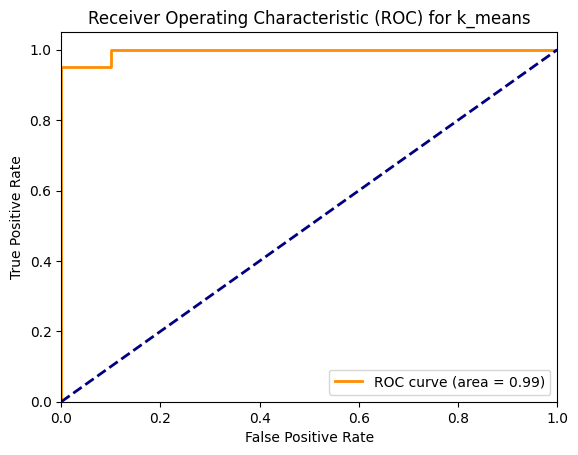

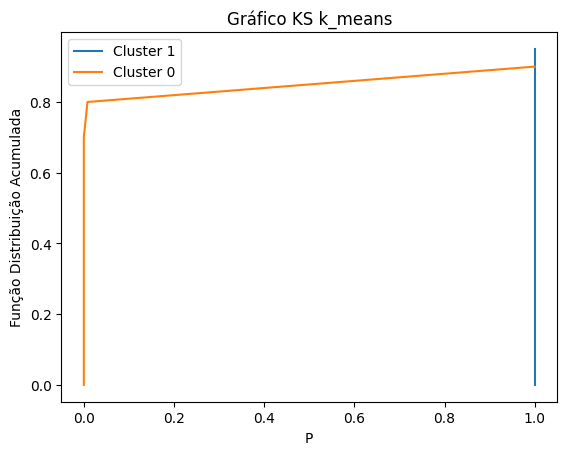

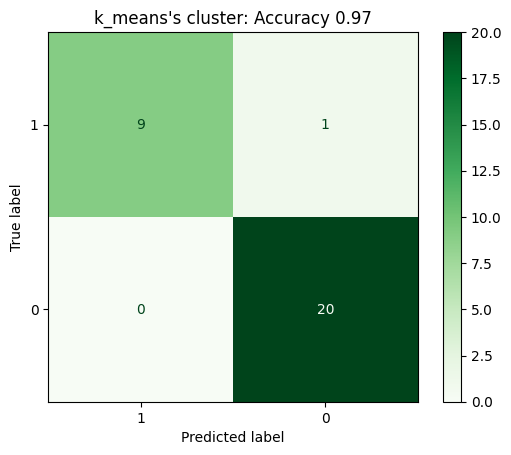


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.95      1.00      0.98        20

    accuracy                           0.97        30
   macro avg       0.98      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



In [51]:
try:
    # Inserindo novas variáveis
    flag = modelos_cluster[0]
    modelo = f'''
                {flag} ~ 
                indep_1
        '''
    modelos_relog(flag=flag, modelo=modelo)
except ValueError as e:
    print(e)

In [52]:
predito = reglog.predict(df_4)
predito.shape

(100,)

In [53]:
predito.head()

53     3.070342e-48
93     1.000000e+00
20     1.365695e-27
177    1.000000e+00
26     1.000000e+00
dtype: float64

In [54]:
df_4['log_reg'] = retorna_classe(predito)
df_4.head()

,indep_1,indep_2,indep_3,indep_4,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg
53,41,24.36,max,max,0,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1,1


In [ ]:
# dump(df_4, './data/05_aula_df_5')
df_5 = load('./data/05_aula_df_5')

df_5['target'] = df_5[['k_means', 'DBSCAN_1', 'DBSCAN_2', 'NN-DBSCAN_1', 'k_NN', 'log_reg']].mean(axis=1)
df_5['target'] = df_5['target'].astype('int64')

df_5 = df_5[df_5.columns[[0, 1, 2, 3, 10, 4, 5, 6, 7, 8, 9]]].copy()
df_5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100 entries, 53 to 45
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   indep_1      100 non-null    int64   
 1   indep_2      100 non-null    float64 
 2   indep_3      100 non-null    category
 3   indep_4      100 non-null    category
 4   target       100 non-null    int64   
 5   k_means      100 non-null    int64   
 6   DBSCAN_1     100 non-null    int64   
 7   DBSCAN_2     100 non-null    int64   
 8   NN-DBSCAN_1  100 non-null    int64   
 9   k_NN         100 non-null    int64   
 10  log_reg      100 non-null    int64   
dtypes: category(2), float64(1), int64(8)
memory usage: 8.0 KB


## SVM

In [56]:
from sklearn import svm

from src.avalia_modelo import Avalia_modelo

In [57]:
df_5.head()

,indep_1,indep_2,indep_3,indep_4,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg
53,41,24.36,max,max,0,0,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1,1,1


In [58]:
def train_test_df_split(df: pd.DataFrame, indep: list, target: str = "target") -> tuple:
    '''
        Função que divide o DataFrame em treino e teste
    '''
    df_train, df_test = train_test_df(df)

    X_train = df_train.loc[:, indep].copy()
    X_test = df_test.loc[:, indep].copy()

    y_train = df_train.loc[:, target].copy()
    y_test = df_test.loc[:, target].copy()

    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"y_test: {y_test.shape}")

    return df_train, df_test, X_train, X_test, y_train, y_test

In [59]:
indep = df_5.columns[[0]]
target = "target"

df_5_train, df_5_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_5, indep=indep)

df_train: (70, 11)
df_test: (30, 11)
X_train: (70, 1)
X_test: (30, 1)
y_train: (70,)
y_test: (30,)


In [60]:
# SVC for classification
clf = svm.SVC(kernel='linear') # 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [61]:
avalia_modelo = Avalia_modelo(
    df=df_5_test,
    target=target,
    indep=indep,
    modelo=clf
)

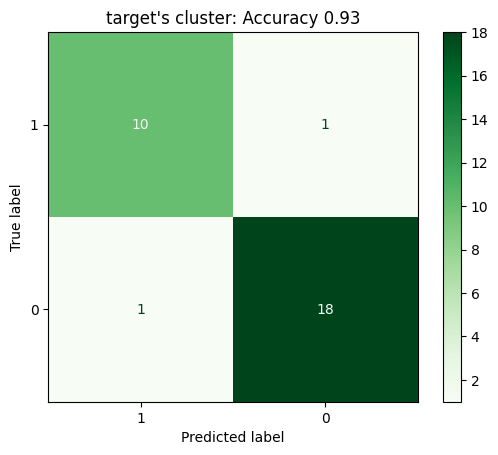


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        11
           1       0.95      0.95      0.95        19

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

   Acurácia  Precision  Recall  F1-Score      KS     AUC    GINI
0    0.9333     0.9474  0.9474    0.9474  0.8565  0.9282  0.8565


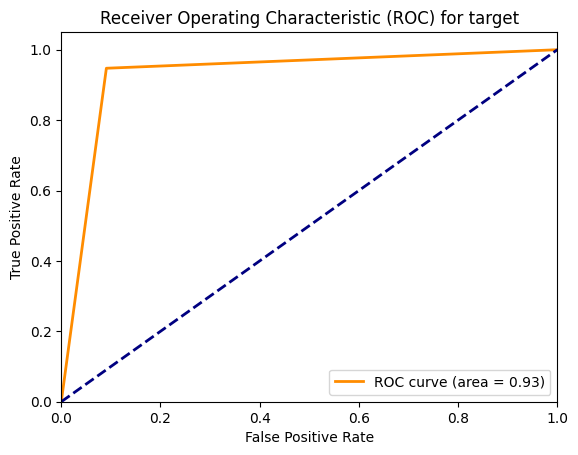

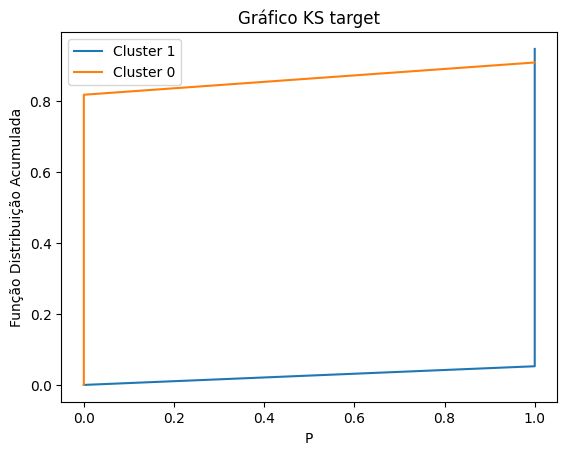

In [62]:
avalia_modelo.metricas()

In [63]:
df_5_test.head()

,indep_1,indep_2,indep_3,indep_4,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg
132,18,5.53,min,min,1,1,1,1,1,1,1
143,14,5.61,min,min,1,1,1,1,1,1,1
121,14,5.37,min,min,1,1,1,1,1,1,1
91,22,7.22,min,min,1,1,1,1,1,1,1
74,20,12.19,min,med,1,1,1,1,1,1,1


In [64]:
df_5_train = pd.get_dummies(df_5_train[df_5_train.columns[[0,1,2,3,4]]], columns=['indep_3', 'indep_4']).copy()
df_5_train = df_5_train[df_5_train.columns[[0,1,3,4,5,6,7,2]]].copy()
df_5_train.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target
93,9,8.05,0,1,0,1,0,1
20,36,19.92,1,0,0,0,1,0
177,13,7.73,1,0,1,0,0,1
0,21,6.37,0,1,1,0,0,1
154,40,22.80,1,0,0,0,1,0


In [65]:
df_5_test = pd.get_dummies(df_5_test[df_5_test.columns[[0,1,2,3,4]]], columns=['indep_3', 'indep_4']).copy()
df_5_test = df_5_test[df_5_test.columns[[0,1,3,4,5,6,7,2]]].copy()
df_5_test.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target
132,18,5.53,0,1,1,0,0,1
143,14,5.61,0,1,1,0,0,1
121,14,5.37,0,1,1,0,0,1
91,22,7.22,0,1,1,0,0,1
74,20,12.19,0,1,0,1,0,1


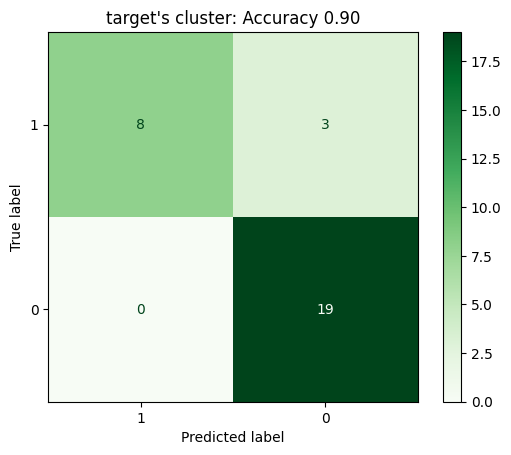


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84        11
           1       0.86      1.00      0.93        19

    accuracy                           0.90        30
   macro avg       0.93      0.86      0.88        30
weighted avg       0.91      0.90      0.90        30

   Acurácia  Precision  Recall  F1-Score      KS     AUC    GINI
0       0.9     0.8636     1.0    0.9268  0.7273  0.8636  0.7273


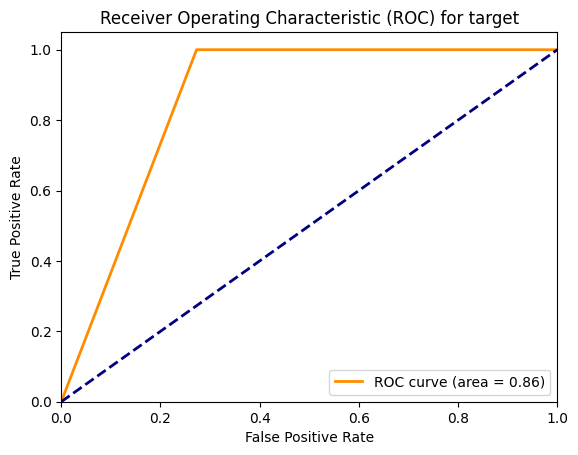

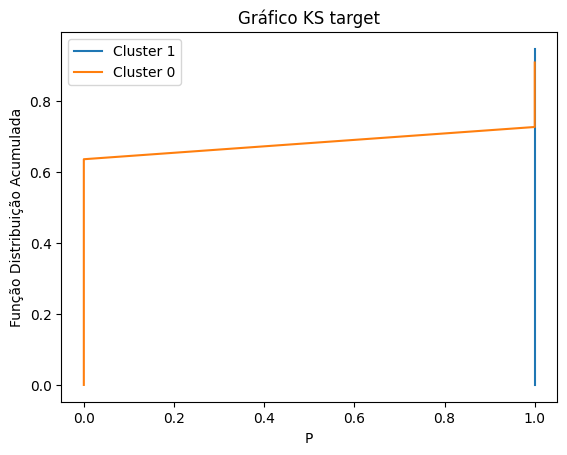

In [66]:
indep = df_5_test.columns[:-1]

X_train = df_5_train.loc[:, indep].copy()
X_test = df_5_test.loc[:, indep].copy()

y_train = df_5_train.loc[:, target].copy()
y_test = df_5_test.loc[:, target].copy()

# SVC for classification
clf = svm.SVC(kernel='poly') # 'linear', 'poly', 'rbf', 'sigmoid'
clf.fit(X_train, y_train)

avalia_modelo = Avalia_modelo(
    df=df_5_test,
    target=target,
    indep=indep,
    modelo=clf
)
avalia_modelo.metricas()

In [67]:
df_5.head()

,indep_1,indep_2,indep_3,indep_4,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg
53,41,24.36,max,max,0,0,0,0,0,0,0
93,9,8.05,min,med,1,1,1,1,1,1,1
20,36,19.92,max,max,0,0,0,0,0,0,0
177,13,7.73,max,min,1,1,1,1,1,1,1
26,17,6.21,max,min,1,1,1,1,1,1,1


In [68]:
X_test.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max
132,18,5.53,0,1,1,0,0
143,14,5.61,0,1,1,0,0
121,14,5.37,0,1,1,0,0
91,22,7.22,0,1,1,0,0
74,20,12.19,0,1,0,1,0


In [69]:
pd.get_dummies(df_5[df_5.columns[[0,1,2,3]]], columns=['indep_3', 'indep_4']).head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max
53,41,24.36,1,0,0,0,1
93,9,8.05,0,1,0,1,0
20,36,19.92,1,0,0,0,1
177,13,7.73,1,0,1,0,0
26,17,6.21,1,0,1,0,0


In [70]:
df_5[df_5.columns[[0,1,2,3]]].head()

,indep_1,indep_2,indep_3,indep_4
53,41,24.36,max,max
93,9,8.05,min,med
20,36,19.92,max,max
177,13,7.73,max,min
26,17,6.21,max,min


In [71]:
df_5 = pd.get_dummies(df_5, columns=['indep_3', 'indep_4'])
df_5 = df_5[df_5.columns[[0, 1, 9, 10, 11, 12, 13, 2, 3, 4, 5, 6, 7, 8]]].copy()
df_5.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1


In [ ]:
df_5['SVM'] = clf.predict(df_5[df_5.columns[[0,1,2,3,4,5,6]]])

# dump(df_5, './data/05_aula_df_5')
df_6 = load('./data/05_aula_df_5')

df_6.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1


## Decision tree

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
indep = df_6.columns[[0, 1, 2, 3, 4, 5, 6]]

df_6_train, df_6_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_6, indep=indep)

df_train: (70, 15)
df_test: (30, 15)
X_train: (70, 7)
X_test: (30, 7)
y_train: (70,)
y_test: (30,)


In [75]:
# Instanciando os objetos com os algoritmos de árvores
clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, random_state=42)

clf.fit(X_train, y_train)

# Verificando as métricas treino
mse2 = clf.score(X_test, y_test)

template = f"O R² da árvore com profundidade "
template += f"{clf.get_depth()} é: {mse2:.2f}".replace(".",",")
print("Treinamento")
print(template)

Treinamento
O R² da árvore com profundidade 3 é: 0,93


In [76]:
# Instanciando uma DataFrame com a importância e o nome de cada variável
importances = pd.DataFrame(
    data={
        "importance": clf.feature_importances_,
        "columns": X_train.columns
        }
    )
importances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   importance  7 non-null      float64
 1   columns     7 non-null      object 
dtypes: float64(1), object(1)
memory usage: 240.0+ bytes


In [77]:
# Ordenando as variáveis por importância para o modelo
importances_largest = importances.sort_values(by="importance", ascending=False)
importances_largest

,importance,columns
6,0.74026,indep_4_max
0,0.25974,indep_1
1,0.00000,indep_2
2,0.00000,indep_3_max
3,0.00000,indep_3_min
4,0.00000,indep_4_min
5,0.00000,indep_4_med


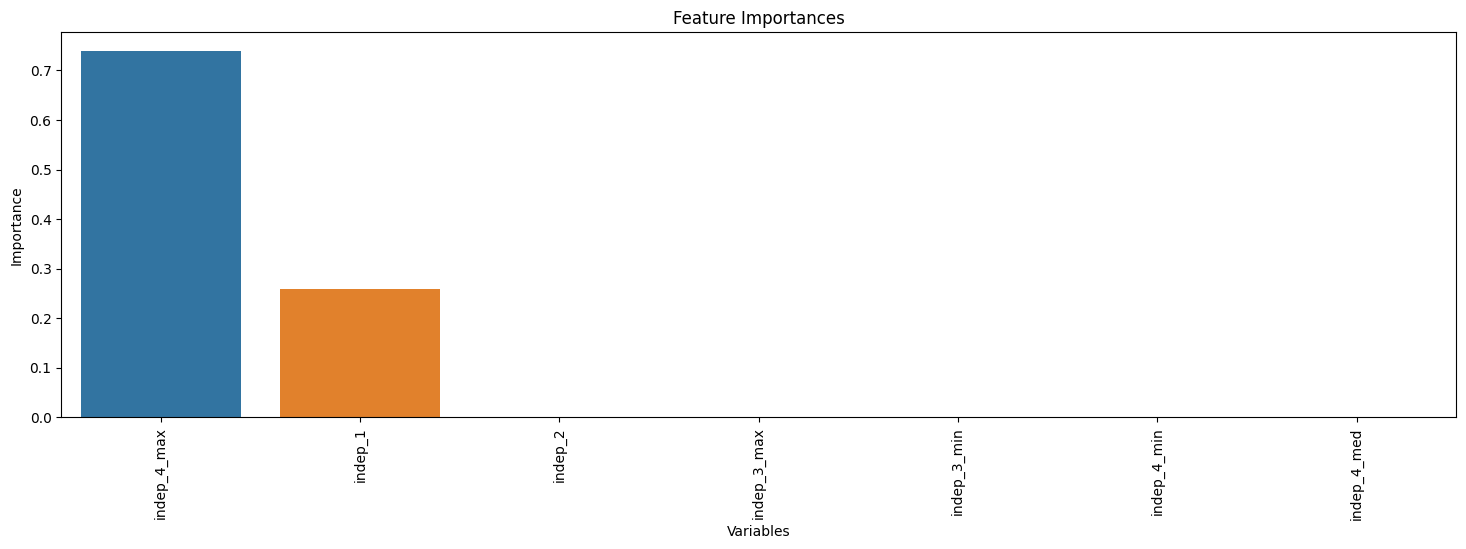

In [78]:
# Plotando as informações de importância das variáveis
plt.figure(figsize=(18, 5))
sns.barplot(
    x="columns",
    y="importance",
    data=importances_largest
)
plt.title("Feature Importances")
plt.xlabel("Variables")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

In [79]:

def test_variable(n: int) -> None:
    '''
    Função para teste de acurrácia de modelos de árvores, com diferentes 
    números de variáveis.
    :param n (int): Número de variáveis no modelo
    '''
    importances_nlargest = importances_largest.loc[importances_largest['importance'].nlargest(n=n).index, :]
    X_train_new = X_train[importances_nlargest['columns']].copy()

    # Treinamento da árvore
    clf.fit(X_train_new, y_train)

    # Verificando as métricas treino
    mse2 = clf.score(X_train_new, y_train)

    template = "O R² da árvore com profundidade "
    template += f"{clf.get_depth()} é: {mse2:.2f}".replace(".",",")
    print("Treinamento")
    print(template)

    return None

In [80]:
# Obtendo árvores com número crescente de variáveis e analisando a acurácia.
for n in range(1, 8):
    print(f"n: {n} ------")
    test_variable(n=n)

n: 1 ------
Treinamento
O R² da árvore com profundidade 1 é: 0,93
n: 2 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00
n: 3 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00
n: 4 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00
n: 5 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00
n: 6 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00
n: 7 ------
Treinamento
O R² da árvore com profundidade 3 é: 1,00


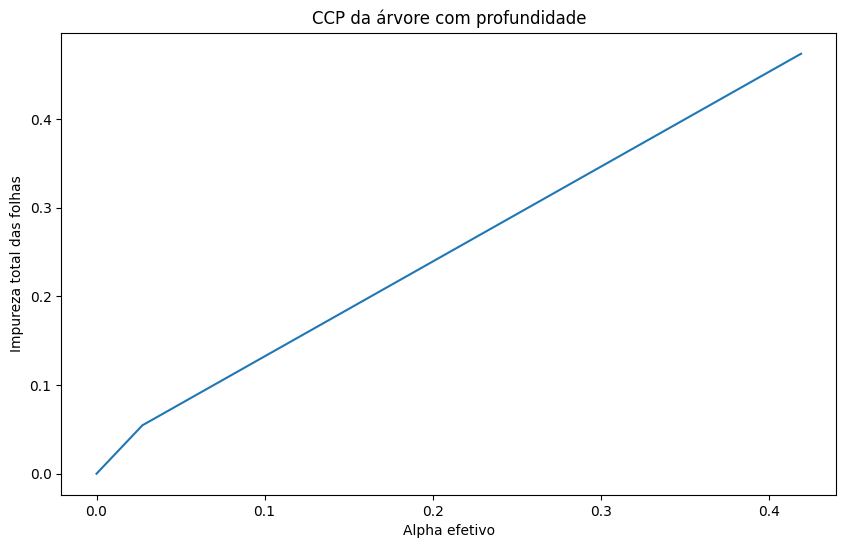

In [81]:
# Obtendo o caminho do CCP para árvore.
clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, random_state=42)

clf.fit(X_train, y_train)

path = clf.cost_complexity_pruning_path(X_test, y_test)
ccp_alphas, impurities_2 = path.ccp_alphas, path.impurities
ccp_alphas = np.unique(ccp_alphas)

plt.figure(figsize=(10, 6))
plt.title(f"CCP da árvore com profundidade")
plt.plot(ccp_alphas, impurities_2)
plt.xlabel("Alpha efetivo")
plt.ylabel("Impureza total das folhas")
plt.show()

In [82]:
ccp_alphas

array([0.        , 0.02730159, 0.41927438])

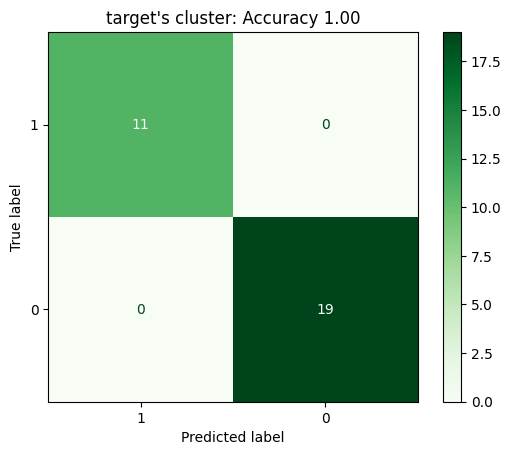


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

   Acurácia  Precision  Recall  F1-Score   KS  AUC  GINI
0       1.0        1.0     1.0       1.0  1.0  1.0   1.0


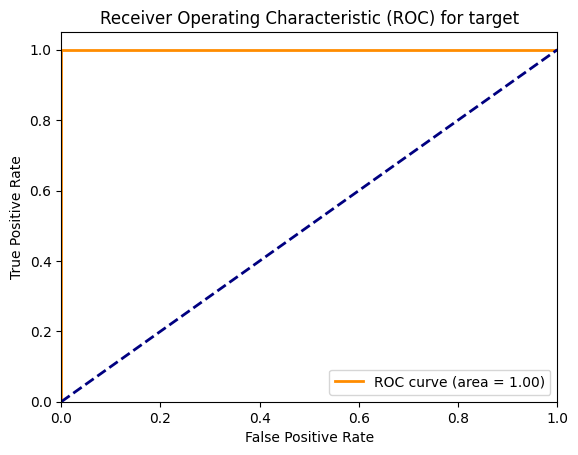

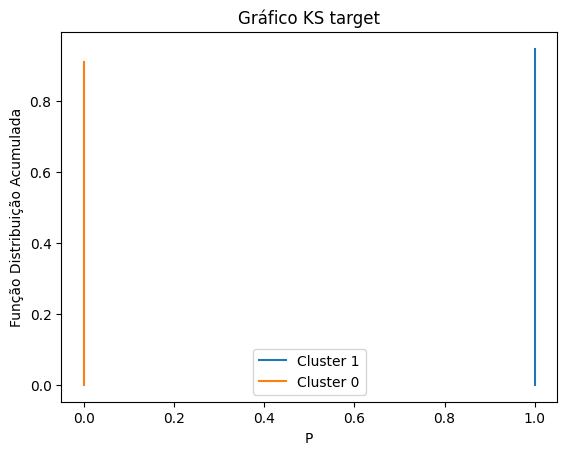

In [83]:
# Create a Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, random_state=42)
clf.fit(X_train, y_train)

avalia_modelo = Avalia_modelo(
    df=df_6_test,
    target='target',
    indep=indep,
    modelo=clf
)
avalia_modelo.metricas()

In [84]:
indep = df_6.columns[[1]]

_, _, X_test, X_train, y_test, y_train = train_test_df_split(df=df_6, indep=indep)

df_train: (70, 15)
df_test: (30, 15)
X_train: (70, 1)
X_test: (30, 1)
y_train: (70,)
y_test: (30,)


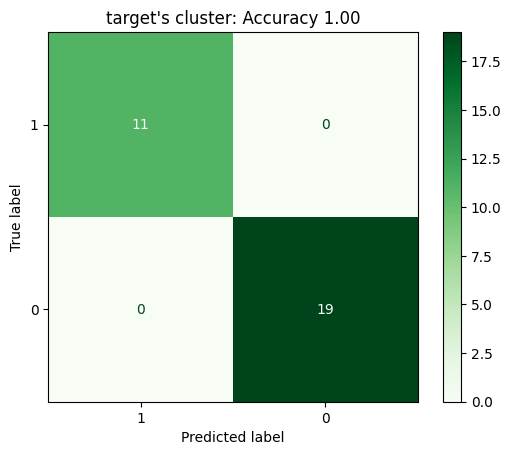


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

   Acurácia  Precision  Recall  F1-Score   KS  AUC  GINI
0       1.0        1.0     1.0       1.0  1.0  1.0   1.0


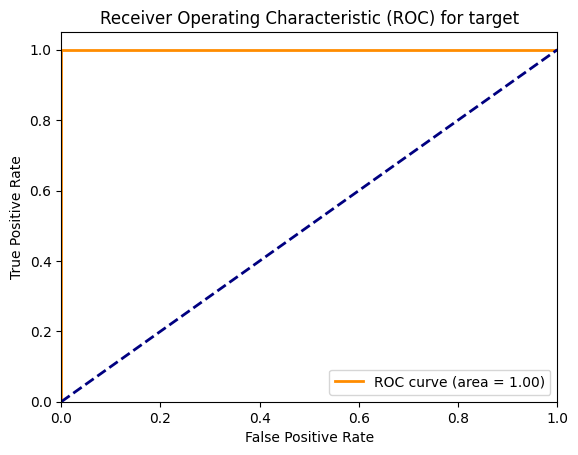

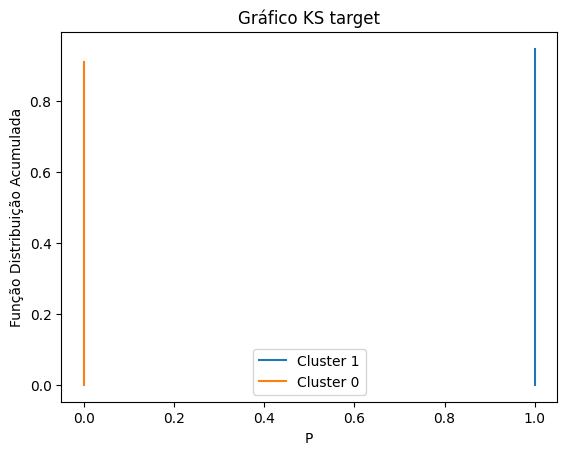

In [85]:
# Create a Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, random_state=42)
clf.fit(X_train, y_train)

avalia_modelo = Avalia_modelo(
    df=df_6_test,
    indep=indep,
    modelo=clf
)
avalia_modelo.metricas()

In [86]:
df_6.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1


In [87]:
df_6['dec_tree'] = clf.predict(df_6.loc[:, indep])
df_6.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1


In [ ]:
# dump(df_6, './data/05_aula_df_6')
df_7 = load('./data/05_aula_df_6')

df_7.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1


## Random Forest

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

In [90]:
indep = df_7.columns[[0, 1, 2, 3, 4, 5, 6]]
df_7_train, df_7_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_7, indep=indep, target=target)

df_train: (70, 16)
df_test: (30, 16)
X_train: (70, 7)
X_test: (30, 7)
y_train: (70,)
y_test: (30,)


In [91]:
# Calcular o Gini
def calcula_gini(RESP, PD):
    #AUC
    auc = roc_auc_score(RESP, PD)
    
    #Gini
    gini = 2*auc -1
    return gini

In [92]:
lista_gini_test=[]
lista_gini_train=[]

grid = list(range(100, 1001, 150))

for num_arvores in grid:
    clf = RandomForestClassifier(
                                    n_estimators=num_arvores,
                                    max_depth=10,
                                    min_samples_leaf=1,
                                    n_jobs=-1,
                                )
    
    clf.fit(X_train,y_train)
    
    gini_test  = calcula_gini(y_test, clf.predict_proba(X_test)[:,1])
    gini_train = calcula_gini(y_train, clf.predict_proba(X_train)[:,1])
    
    lista_gini_test.append(gini_test)
    lista_gini_train.append(gini_train)


In [93]:
zip_gini_train = zip(list(range(100, 1001, 150)), lista_gini_train)
zip_gini_test = zip(list(range(100, 1001, 150)), lista_gini_test)

dict_gini_train = dict(zip_gini_train)
dict_gini_test = dict(zip_gini_test)
print(dict_gini_train)

series_gini_train = pd.Series(dict_gini_train)
series_gini_test = pd.Series(dict_gini_test)
print(series_gini_train)

{100: 1.0, 250: 1.0, 400: 1.0, 550: 1.0, 700: 1.0, 850: 1.0, 1000: 1.0}
100     1.0
250     1.0
400     1.0
550     1.0
700     1.0
850     1.0
1000    1.0
dtype: float64


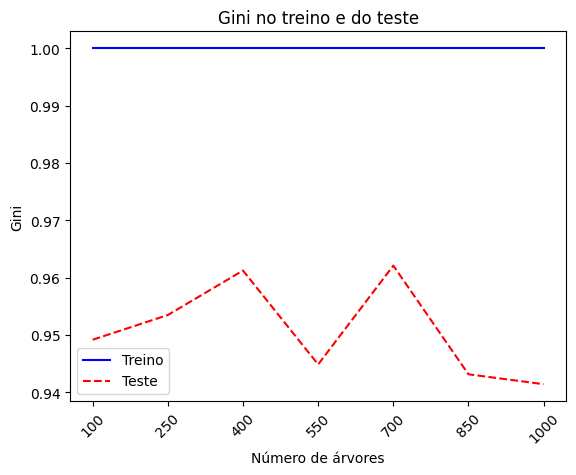

In [94]:
#Plot comparando o gini no treino e no teste
fig, ax = plt.subplots()

ax.plot(series_gini_train, '-b', label='Treino')
ax.plot(series_gini_test,  '--r', label='Teste')
ax.set_title('Gini no treino e do teste')
ax.set_xlabel('Número de árvores')
ax.set_ylabel('Gini')
ax.set_xticks(series_gini_train.index)
ax.set_xticklabels(series_gini_train.index, rotation=45)

leg = ax.legend()

In [95]:
rf = RandomForestClassifier()

params = {
    'max_depth' : [1, 2, 10],
    'min_samples_leaf': [1, 2, 5],
    'n_estimators': list(range(100, 1001, 150))
}

grid_rf = GridSearchCV(
                        estimator=rf,        # Algoritmo a ser utilizado
                        param_grid=params,   # Parâmetros a serem testados
                        scoring='accuracy',  # Metrica de qualidade do modelo
                        cv=5,                # Número de folds para validação cruzada
                        verbose=0,           # Verbosidade do processo
                        n_jobs=-1            # Use all available CPU cores
                    )

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 10], 'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 250, 400, 550, 700, 850, 1000]},
             scoring='accuracy')

In [96]:
grid_rf.cv_results_['params'][:5]

[{'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 100},
 {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 250},
 {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 400},
 {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 550},
 {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 700}]

In [97]:
grid_rf.cv_results_['mean_test_score'][:5]

array([0.93333333, 0.9       , 0.9       , 0.9       , 0.9       ])

In [98]:
print(grid_rf.best_estimator_)

RandomForestClassifier(max_depth=1)


In [99]:
# print os melhores parametros
print(grid_rf.best_estimator_)

# 
print(grid_rf.best_estimator_.score(X_test, y_test))
print(grid_rf.score(X_test, y_test))

RandomForestClassifier(max_depth=1)
0.9
0.9


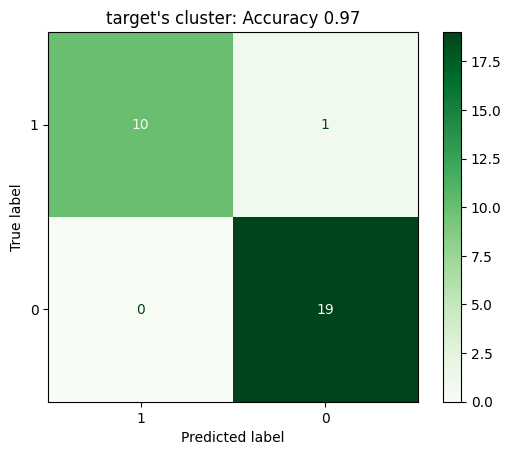


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.95      1.00      0.97        19

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30

   Acurácia  Precision  Recall  F1-Score      KS     AUC    GINI
0    0.9667       0.95     1.0    0.9744  0.9091  0.9545  0.9091


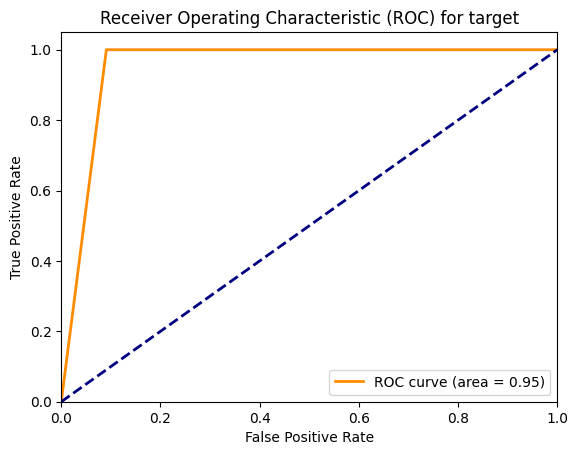

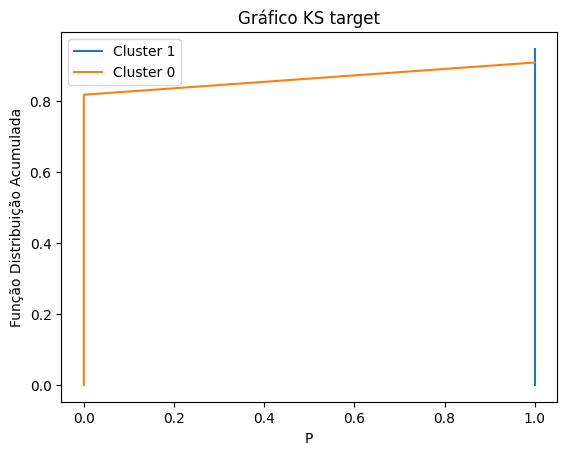

In [100]:
clf = RandomForestClassifier(
                                n_estimators=250,
                                max_depth=1,
                                n_jobs=-1,
                            )
clf.fit(X_train,y_train)

avalia_modelo = Avalia_modelo(
    df=df_7_test,
    indep=indep,
    modelo=clf
)
avalia_modelo.metricas()

In [ ]:
df_7['random_forest'] = clf.predict(df_7.loc[:, indep])

# dump(df_7, './data/05_aula_df_7')
df_8 = load('./data/05_aula_df_7')

df_8.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree,random_forest
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1


## GBM

In [102]:
from sklearn.ensemble import GradientBoostingClassifier

In [103]:
df_8_train, df_8_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_8, indep=indep)

df_train: (70, 17)
df_test: (30, 17)
X_train: (70, 7)
X_test: (30, 7)
y_train: (70,)
y_test: (30,)


In [104]:
gb = GradientBoostingClassifier()

parametros = {
    'max_depth' : [1, 2, 10],
    'min_samples_leaf': [1, 2, 5],
    'n_estimators': list(range(100, 1001, 150)),
    'learning_rate': [0.01, 0.5, 0.1],
}

grid = GridSearchCV(
                        estimator=gb,
                        param_grid=parametros,
                        scoring='roc_auc',
                        verbose=False,
                        cv=2
).fit(X_train, y_train)

grid.best_params_

{'learning_rate': 0.01,
 'max_depth': 1,
 'min_samples_leaf': 2,
 'n_estimators': 1000}

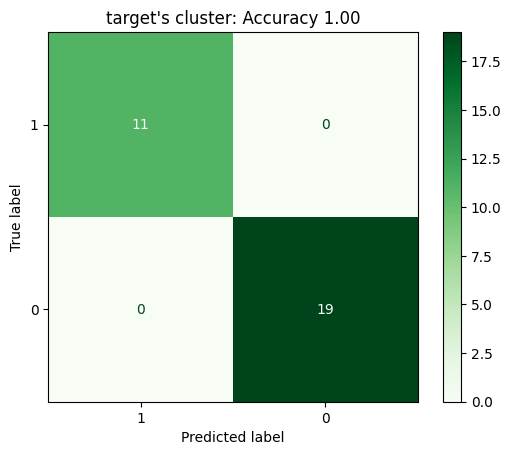


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

   Acurácia  Precision  Recall  F1-Score   KS  AUC  GINI
0       1.0        1.0     1.0       1.0  1.0  1.0   1.0


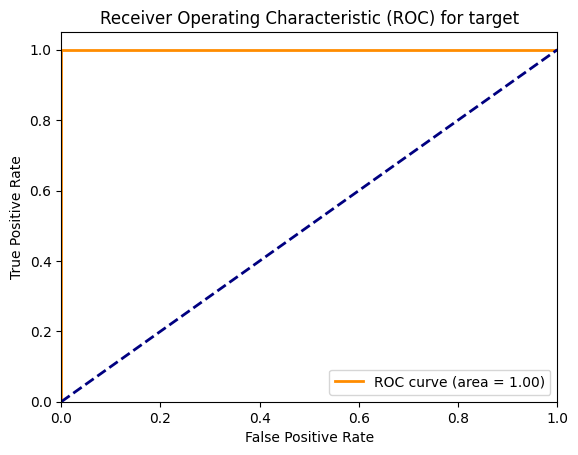

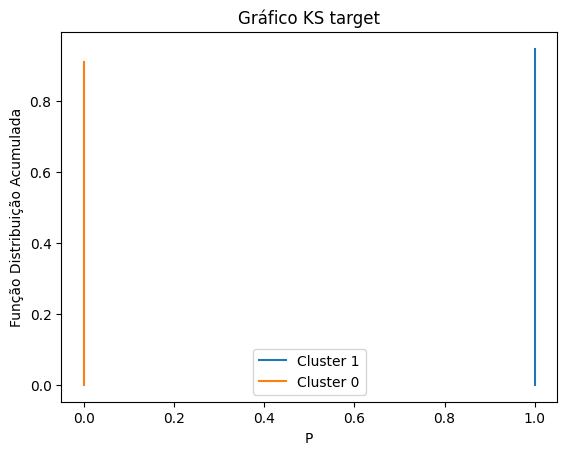

In [105]:
gb = GradientBoostingClassifier(**grid.best_params_)

gb.fit(X_train,y_train)

avalia_modelo = Avalia_modelo(
    df=df_8_test,
    indep=indep,
    modelo=gb
)
avalia_modelo.metricas()

In [ ]:
df_8['gbm'] = gb.predict(df_8.loc[:, indep])

# dump(df_8, './data/05_aula_df_8')
df_9 = load('./data/05_aula_df_8')

df_9.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree,random_forest,gbm
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1


## Naive Bayes

In [107]:
from sklearn.naive_bayes import BernoulliNB

In [108]:
df_9_train, df_9_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_9, indep=indep)

df_train: (70, 18)
df_test: (30, 18)
X_train: (70, 7)
X_test: (30, 7)
y_train: (70,)
y_test: (30,)


In [109]:
nb = BernoulliNB()

parametros = {
    'alpha' : [1.0, 0.5, 0.1, 0.01],
    'fit_prior': [True, False],
}

grid = GridSearchCV(
                        estimator=nb,
                        param_grid=parametros,
                        scoring='roc_auc',
                        verbose=False,
                        cv=2
).fit(X_train, y_train)

grid.best_params_

{'alpha': 0.1, 'fit_prior': True}

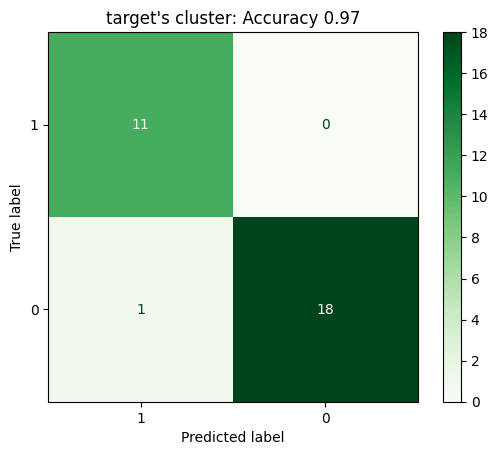


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.95      0.97        19

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

   Acurácia  Precision  Recall  F1-Score      KS     AUC    GINI
0    0.9667        1.0  0.9474     0.973  0.9474  0.9737  0.9474


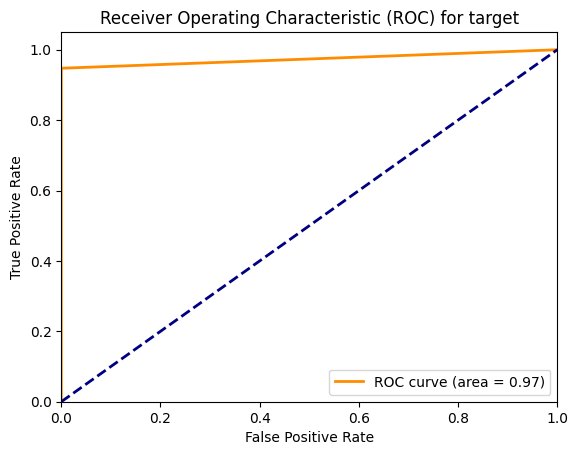

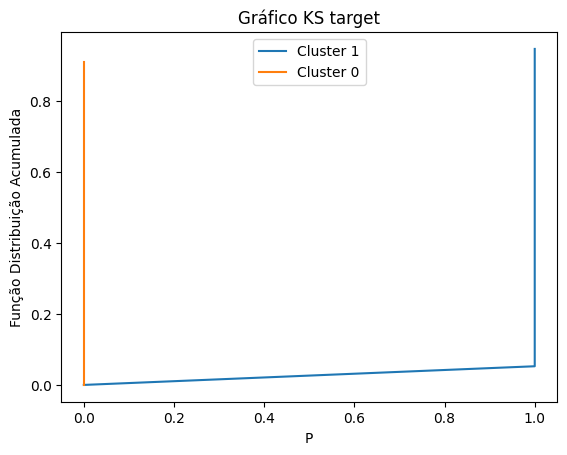

In [110]:
nb = BernoulliNB(**grid.best_params_)

nb.fit(X_train, y_train)

avalia_modelo = Avalia_modelo(
    df=df_9_test,
    indep=indep,
    modelo=nb
)
avalia_modelo.metricas()

In [ ]:
df_9['nb'] = nb.predict(df_9.loc[:, indep])

# dump(df_9, './data/05_aula_df_9')
df_10 = load('./data/05_aula_df_9')

df_10.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree,random_forest,gbm,nb
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1


## Redes Neurais

In [112]:
# TensorFlow e tf.keras
import tensorflow as tf
from tensorflow import keras

2026-07-18 20:33:57.265336: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-18 20:33:57.274386: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-18 20:33:57.390550: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-18 20:33:57.393215: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are us

In [113]:
df_10_train, df_10_test, X_test, X_train, y_test, y_train = train_test_df_split(df=df_10, indep=indep)

df_train: (70, 19)
df_test: (30, 19)
X_train: (70, 7)
X_test: (30, 7)
y_train: (70,)
y_test: (30,)


In [114]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='softmax'),
    keras.layers.Dense(1, activation='sigmoid'),
])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 7)                 0         
                                                                 
 dense (Dense)               (None, 64)                512       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,625
Trainable params: 2,625
Non-trainable params: 0
_________________________________________________________________


In [115]:
model.fit(
    X_train,
    y_train,
    epochs=55,
    batch_size=32,
    verbose=0
)

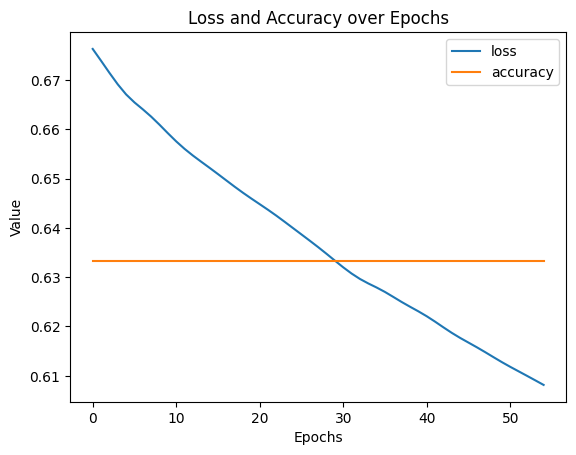

In [116]:
pd.DataFrame(model.history.history).plot(
    title='Loss and Accuracy over Epochs',
    xlabel='Epochs',
    ylabel='Value',
)
plt.show()

In [117]:
model.predict(df_10.loc[:, indep])[:10]

4/4 [==============================] - 0s 3ms/step


array([[0.52402633],
       [0.5986518 ],
       [0.53106815],
       [0.58167195],
       [0.5973211 ],
       [0.61545503],
       [0.5263116 ],
       [0.5881101 ],
       [0.58637077],
       [0.5975025 ]], dtype=float32)

1/1 [==============================] - 0s 25ms/step


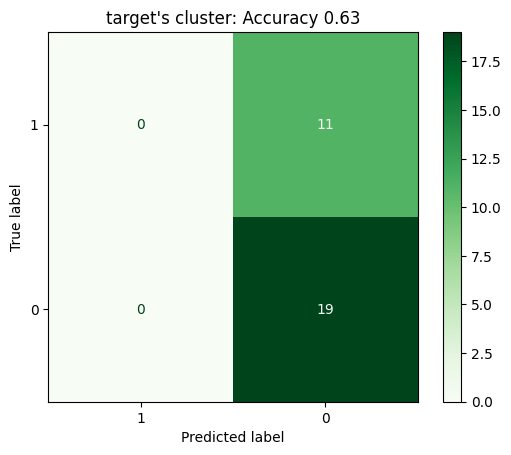


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.63      1.00      0.78        19

    accuracy                           0.63        30
   macro avg       0.32      0.50      0.39        30
weighted avg       0.40      0.63      0.49        30

1/1 [==============================] - 0s 25ms/step
   Acurácia  Precision  Recall  F1-Score   KS  AUC  GINI
0    0.6333     0.6333     1.0    0.7755  0.0  0.5   0.0


/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


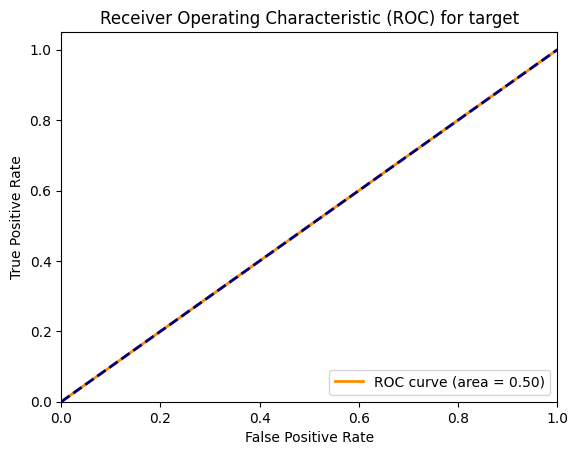

1/1 [==============================] - 0s 22ms/step


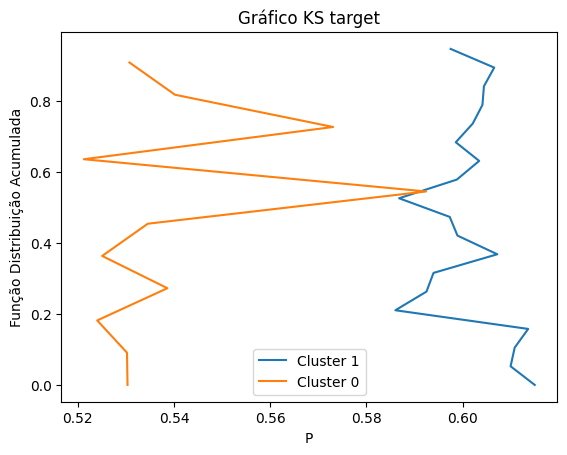

In [118]:
avalia_modelo = Avalia_modelo(
    df=df_10_test,
    indep=indep,
    troca_classe=True,
    modelo=model
)
avalia_modelo.metricas()

In [119]:
df_10['NN'] = retorna_classe(model.predict(df_10.loc[:, indep]))
df_10.head()

4/4 [==============================] - 0s 2ms/step


,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree,random_forest,gbm,nb,NN
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1


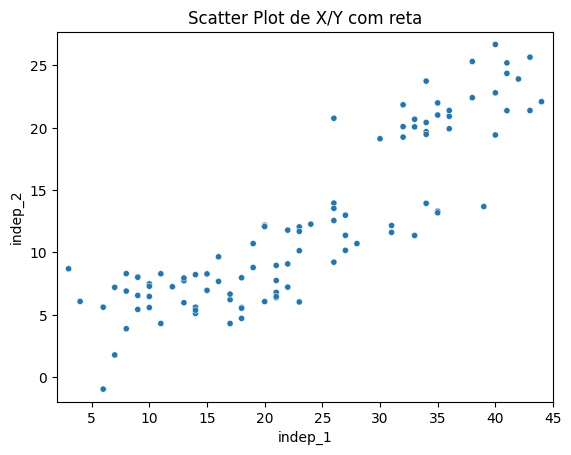

In [120]:
sns.scatterplot(
    x='indep_1',
    y='indep_2',
    hue='NN',
    legend=False,
    s=20,
    data=df_10
)
plt.title('Scatter Plot de X/Y com reta')
plt.xlabel('indep_1')
plt.xlim(df_4_copy['indep_1'].min()-1, df_4_copy['indep_1'].max()+1)
plt.ylabel('indep_2')
plt.ylim(df_4_copy['indep_2'].min()-1, df_4_copy['indep_2'].max()+1)
plt.show()

In [ ]:
# dump(df_10, './data/05_aula_df_10')
df_11 = load('./data/05_aula_df_10')

df_11.head()

,indep_1,indep_2,indep_3_max,indep_3_min,indep_4_min,indep_4_med,indep_4_max,target,k_means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1,k_NN,log_reg,SVM,dec_tree,random_forest,gbm,nb,NN
53,41,24.36,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
93,9,8.05,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
20,36,19.92,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
177,13,7.73,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
26,17,6.21,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
